In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import os
import re
base_path = 'output/'

dfs_all = []

# loop over encoders
for encoder in os.listdir(base_path):
    encoder_path = os.path.join(base_path, encoder)

    if not os.path.isdir(encoder_path) or encoder == '.ipynb_checkpoints':
        continue

    print('%%%%%%%%%%%%%%%%%%%%%%')
    print(encoder)

    dfs = []

    # loop over seeds
    for seed_dir in os.listdir(encoder_path):
        seed_path = os.path.join(encoder_path, seed_dir)

        if not os.path.isdir(seed_path):
            continue

        # extract seed number (seed1 → 1)
        seed = int(re.search(r'\d+', seed_dir).group())

        # loop over result files
        for file in glob.glob(os.path.join(seed_path, 'results_hafl_life_*.csv')):

            # extract half-life from filename
            hl = int(re.search(r'hafl_life_(\d+)', file).group(1))

            df = pd.read_csv(file)

            df['encoder'] = encoder
            df['seed'] = seed
            df['half_life'] = hl

            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    # keep your original swap if still needed
    df['temp'] = df['model']
    df['model'] = df['time_window']
    df['time_window'] = df['temp']
    df.drop(columns='temp', inplace=True)

    # same aggregation as before
    plot_df = (
        df.groupby(
            ["encoder", "seed", "model", "time_window", "half_life"],
            as_index=False
        )[["recall@10", "ndcg@10"]]
        .mean()
    )

    dfs_all.append(plot_df)

# final dataframe
df = pd.concat(dfs_all, ignore_index=True)

%%%%%%%%%%%%%%%%%%%%%%
embeddinggemma-300m
%%%%%%%%%%%%%%%%%%%%%%
all-MiniLM-L6-v2
%%%%%%%%%%%%%%%%%%%%%%
gte-multilingual-base
%%%%%%%%%%%%%%%%%%%%%%
msmarco-bert-base-dot-v5
%%%%%%%%%%%%%%%%%%%%%%
msmarco-bert-base-dot-v5_twotower
%%%%%%%%%%%%%%%%%%%%%%
all-MiniLM-L6-v2_twotower


In [3]:
encoder_names = {
    'embeddinggemma-300m': 'Gemma-300M',
    'all-MiniLM-L6-v2': 'MiniLM-L6',
    'gte-multilingual-base': 'GTE-Multi',
    'msmarco-bert-base-dot-v5': 'BERT-MSMARCO',
}


df['enc'] = df['encoder'].map(encoder_names)

model_names = {
    'deepseek-r1':'deepseek',
    'gemini-2.0-flash': 'gemini',
    'llama3.2:3b-instruct-q8_0':'llama'
    }

df['model'] = df['model'].map(model_names)

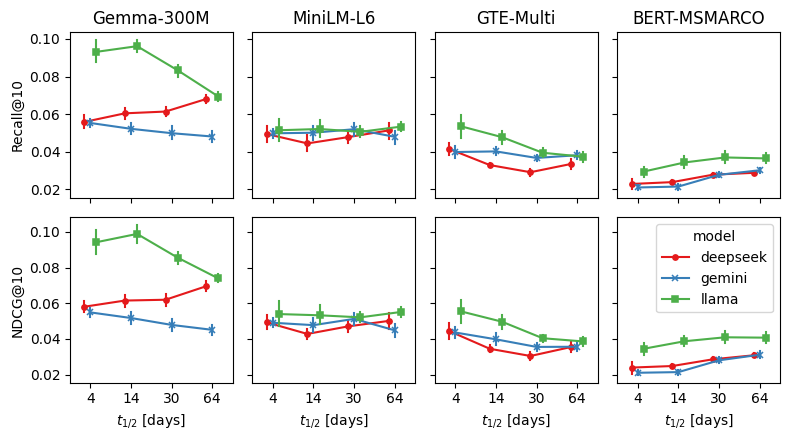

In [8]:
encoders = df['enc'].unique()

fig, axes = plt.subplots(
    2, len(encoders),
    figsize=(8, 4.5),
    sharey='row',
    sharex=True
)

for i, enc in enumerate(encoders):
    
    temp = df[df['enc'] == enc]
    
    # Recall@10
    sns.pointplot(
        data=temp,
        x='half_life',
        y='recall@10',
        hue='model',
        ax=axes[0, i],
        palette='Set1',
        dodge=0.3,
        markers=["o","x","s"],
        linewidth = 1.5
    )
    
    # NDCG@10
    sns.pointplot(
        data=temp,
        x='half_life',
        y='ndcg@10',
        hue='model',
        ax=axes[1, i],
        palette='Set1',
        dodge=0.3,
        markers=["o","x","s"],
        linewidth = 1.5)
    
    axes[0, i].set_title(enc)
    axes[1, i].set_xlabel(r"$t_{1/2}$ [days]")
    if i != 3:
        axes[0, i].get_legend().remove()
        axes[1, i].get_legend().remove()

for ax in axes[0, :]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

axes[0, 0].set_ylabel("Recall@10")
axes[1, 0].set_ylabel("NDCG@10")


    


plt.tight_layout()
plt.savefig("recall_vs_halflife.pdf", bbox_inches='tight')

plt.show()